In [1]:
# imports
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import shap

# loading dataset
import kagglehub

# downloading latest version
path = kagglehub.dataset_download("formyuse/heart-disease-csv")
print("Path to dataset files:", path)

file_path = os.path.join(path, "heart-disease.csv")
data = pd.read_csv(file_path)

data.head()
data.rename(columns={"target": "heart_disease"}, inplace=True)

100%|██████████| 3.41k/3.41k [00:00<00:00, 2.18MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/formyuse/heart-disease-csv/versions/1


In [2]:
# splitting data
X = data.drop("heart_disease", axis=1)
y = data["heart_disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# training
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# evaluating
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8524590163934426
Confusion matrix:
 [[25  4]
 [ 5 27]]


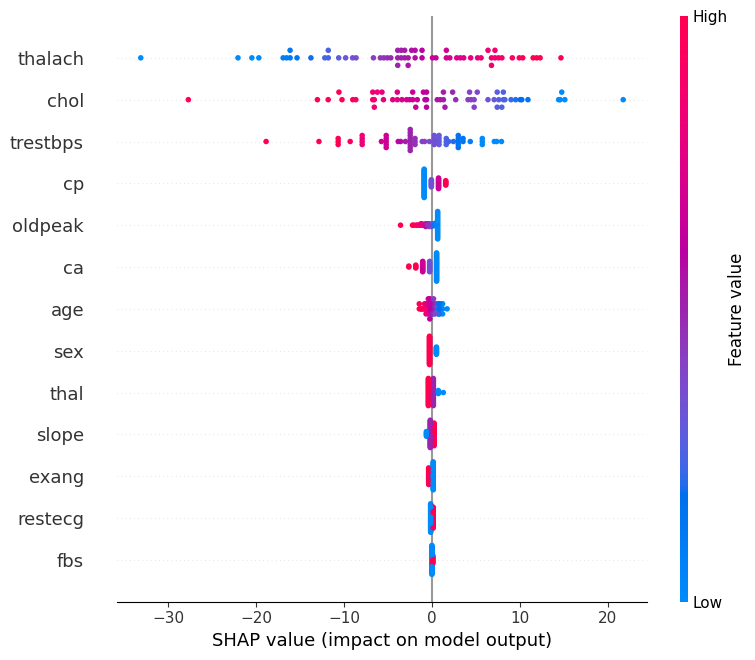

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')
Mean SHAP (male): [0.56547389 0.28191079 0.82846822 3.49764441 6.34841159 0.02607749
 0.14398399 8.65962233 0.23399105 0.6681659  0.24122968 0.73465838
 0.34717292]
Mean SHAP (female): [0.7757215  0.50117473 0.72038435 6.68697766 7.69879658 0.02619038
 0.14296386 5.79353042 0.21300567 0.99200825 0.31676568 0.73040478
 0.25628683]


In [14]:
# SHAP analysis
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# summary plot
shap.summary_plot(shap_values, X_test)
print(X_test.columns)

# gender-based analysis
male_indices = (X_test["sex"] == 1).values
female_indices = (X_test["sex"] == 0).values

male_shap = shap_values[male_indices]
female_shap = shap_values[female_indices]

print("Mean SHAP (male):", np.mean(np.abs(male_shap.values), axis=0))
print("Mean SHAP (female):", np.mean(np.abs(female_shap.values), axis=0))

In [5]:
!pip install dice-ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.1 MB/s eta 0:00:00


In [15]:
import dice_ml
from dice_ml import Dice

# preparing data for DiCE
data_dice = data.copy()

# identifying continuous features
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# creating DiCE data object
dice_data = dice_ml.Data(
    dataframe=data_dice,
    continuous_features=continuous_features,
    outcome_name='heart_disease'
)

# creating model object
dice_model = dice_ml.Model(model=model, backend="sklearn")

# creating explainer
explainer = Dice(dice_data, dice_model)

# Generating counterfactual
# picking one instance from test set
query_instance = X_test.iloc[0:1]

cf = explainer.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite"
)

cf.visualize_as_dataframe()

  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/usr/local/lib/python3.12/dist-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances

Query instance (original outcome : 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heart_disease
0,57,1,0,150,276,0,0,112,1,0.6,1,1,1,0



Diverse Counterfactual set (new outcome: 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heart_disease
0,57,1,3,150,147,0,0,200,1,0.6,1,3,1,1
1,57,1,0,106,150,0,0,195,1,0.6,1,0,1,1
2,57,1,0,106,150,0,0,195,1,0.6,1,0,3,1
